Checking the data

In [ ]:
import pandas as pd

# Load the dataset to inspect it
file_path = 'loan_data.csv'
data = pd.read_csv(file_path)

# Display a sample of the dataset and its basic info
data_info = data.info()
data_sample = data.head()

data_info, data_sample


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

(None,
    person_age person_gender person_education  person_income  person_emp_exp  \
 0        22.0        female           Master        71948.0               0   
 1        21.0        female      High School        12282.0               0   
 2        25.0        female      High School        12438.0               3   
 3        23.0        female         Bachelor        79753.0               0   
 4        24.0          male           Master        66135.0               1   
 
   person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
 0                  RENT    35000.0    PERSONAL          16.02   
 1                   OWN     1000.0   EDUCATION          11.14   
 2              MORTGAGE     5500.0     MEDICAL          12.87   
 3                  RENT    35000.0     MEDICAL          15.23   
 4                  RENT    35000.0     MEDICAL          14.27   
 
    loan_percent_income  cb_person_cred_hist_length  credit_score  \
 0                 0.49                     

Converting categorical Variables

In [ ]:
# Perform one-hot encoding for categorical variables
categorical_columns = ['person_gender', 'person_education', 'person_home_ownership',
                       'loan_intent', 'previous_loan_defaults_on_file']

# One-hot encoding using pandas
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Check the first few rows to verify encoding
data_encoded_sample = data_encoded.head()
data_encoded_sample


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,True,False,False,True,False,False,False,True,False,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,False,True,False,True,False,False,False,False,True
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,False,False,False,False,True,False,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,False,...,False,False,False,True,False,False,True,False,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,True,...,True,False,False,True,False,False,True,False,False,False


Checking class distribution (Potential imbalance)

<ipython-input-5-5ae30a85bf72>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=data_encoded, palette='viridis')


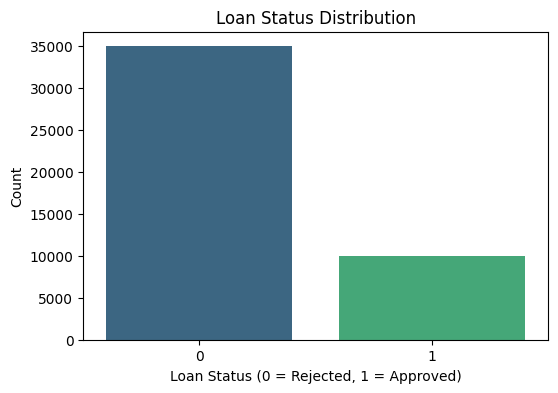

(loan_status
 0    0.777778
 1    0.222222
 Name: proportion, dtype: float64,
 loan_status                           1.000000
 loan_percent_income                   0.384880
 loan_int_rate                         0.332005
 person_home_ownership_RENT            0.255239
 loan_amnt                             0.107714
 loan_intent_MEDICAL                   0.065195
 loan_intent_HOMEIMPROVEMENT           0.033838
 person_home_ownership_OTHER           0.013645
 person_education_Bachelor             0.004728
 person_education_Doctorate            0.001833
 person_education_High School          0.001277
 person_gender_male                   -0.000561
 person_education_Master              -0.004741
 credit_score                         -0.007647
 cb_person_cred_hist_length           -0.014851
 person_emp_exp                       -0.020481
 person_age                           -0.021476
 loan_intent_PERSONAL                 -0.022488
 loan_intent_EDUCATION                -0.064006
 loan_inte

In [ ]:
class_distribution = data_encoded['loan_status'].value_counts(normalize=True)


correlation_matrix = data_encoded.corr()


import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=data_encoded, palette='viridis')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Count')
plt.show()

# Top correlations with loan_status
correlation_with_target = correlation_matrix['loan_status'].sort_values(ascending=False)

class_distribution, correlation_with_target


Data preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into features (X) and target (y)
X = data_encoded.drop(columns=['loan_status'])
y = data_encoded['loan_status']

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Verify the shape of the preprocessed data
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((36000, 22), (9000, 22), (36000,), (9000,))

Imbalance handling with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the new distribution of the target variable after SMOTE
resampled_class_distribution = y_train_resampled.value_counts(normalize=True)
resampled_class_distribution


,proportion
loan_status,
0,0.5
1,0.5


Training classifiers using resampled class distribution

Logistic Regression Accuracy: 0.8656


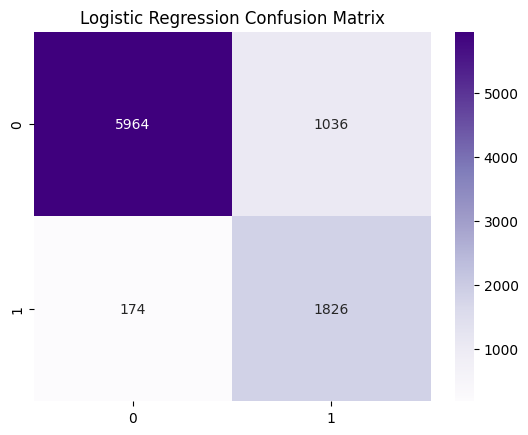

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.91      7000
           1       0.64      0.91      0.75      2000

    accuracy                           0.87      9000
   macro avg       0.80      0.88      0.83      9000
weighted avg       0.90      0.87      0.87      9000

K-Nearest Neighbors Accuracy: 0.8638


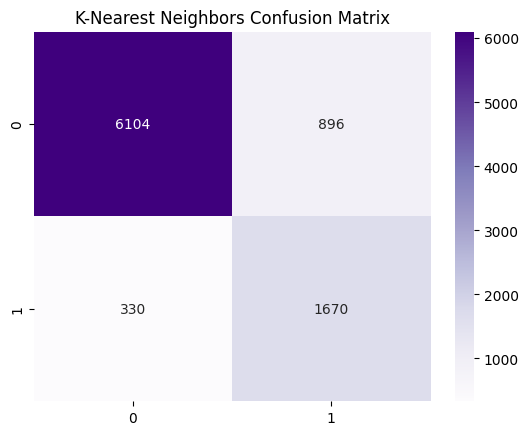

K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91      7000
           1       0.65      0.83      0.73      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.85      0.82      9000
weighted avg       0.88      0.86      0.87      9000

Naive Bayes Accuracy: 0.7540


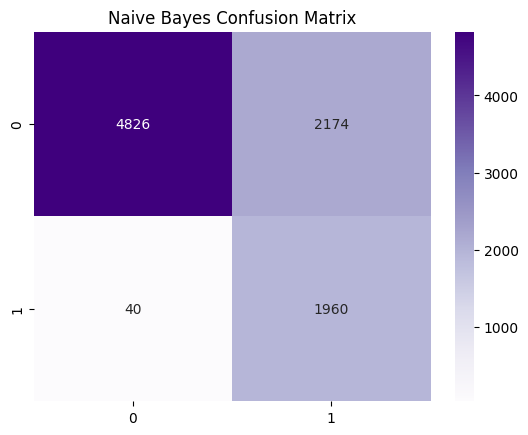

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.69      0.81      7000
           1       0.47      0.98      0.64      2000

    accuracy                           0.75      9000
   macro avg       0.73      0.83      0.73      9000
weighted avg       0.88      0.75      0.77      9000

Support Vector Machine Accuracy: 0.8753


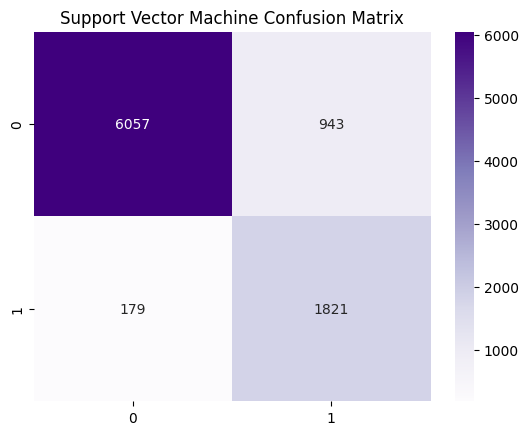

Support Vector Machine Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.87      0.92      7000
           1       0.66      0.91      0.76      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.89      0.84      9000
weighted avg       0.90      0.88      0.88      9000

Random Forest Accuracy: 0.9187


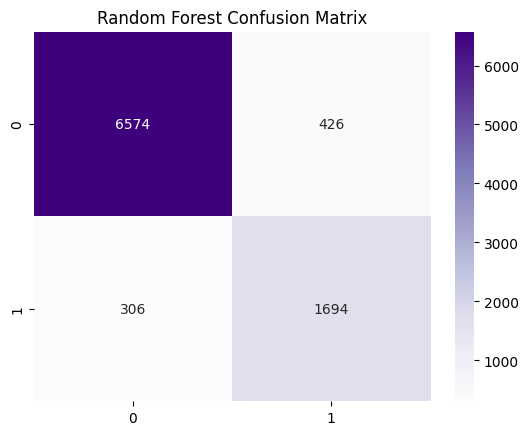

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95      7000
           1       0.80      0.85      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.89      0.88      9000
weighted avg       0.92      0.92      0.92      9000

Decision Tree Accuracy: 0.8869


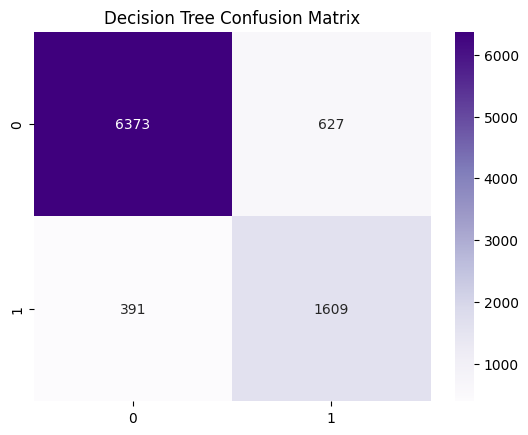

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.93      7000
           1       0.72      0.80      0.76      2000

    accuracy                           0.89      9000
   macro avg       0.83      0.86      0.84      9000
weighted avg       0.89      0.89      0.89      9000

XGBoost Accuracy: 0.9304


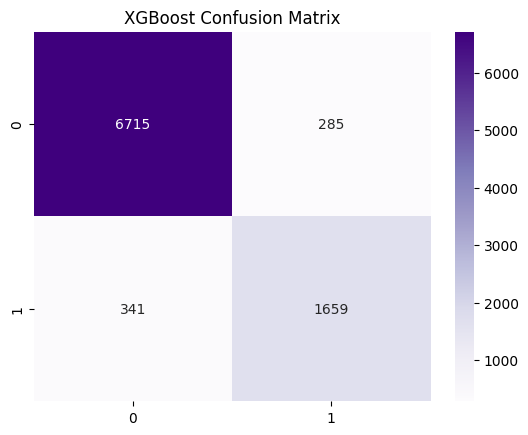

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96      7000
           1       0.85      0.83      0.84      2000

    accuracy                           0.93      9000
   macro avg       0.90      0.89      0.90      9000
weighted avg       0.93      0.93      0.93      9000


Model Performance Summary:
Logistic Regression: 0.8656
K-Nearest Neighbors: 0.8638
Naive Bayes: 0.7540
Support Vector Machine: 0.8753
Random Forest: 0.9187
Decision Tree: 0.8869
XGBoost: 0.9304


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning classifiers
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

model_performance = {}

# Helper function to train and evaluate models
def evaluate_model(model, model_name):
    # Fit the model
    model.fit(X_train_resampled, y_train_resampled)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # Classification report
    print(f"{model_name} Classification Report:\n", classification_report(y_test, y_pred))

    # Store the accuracy
    model_performance[model_name] = accuracy

# Logistic Regression
logreg = LogisticRegression()
evaluate_model(logreg, "Logistic Regression")

# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=3)  # You can tune this
evaluate_model(knn, "K-Nearest Neighbors")

# Naive Bayes
nb = GaussianNB()
evaluate_model(nb, "Naive Bayes")

# Support Vector Machine (SVM)
svm = SVC(kernel='rbf')  # Linear kernel for simplicity; try 'rbf' for non-linear
evaluate_model(svm, "Support Vector Machine")

# Random Forest
rf = RandomForestClassifier(n_estimators=100)  # You can tune the number of trees
evaluate_model(rf, "Random Forest")

# Decision Tree
dt = DecisionTreeClassifier()
evaluate_model(dt, "Decision Tree")

xgb = XGBClassifier()
evaluate_model(xgb, "XGBoost")

# Summarize model performance
print("\nModel Performance Summary:")
for model_name, accuracy in model_performance.items():
    print(f"{model_name}: {accuracy:.4f}")



Training classifiers using original class distribution

Logistic Regression Accuracy: 0.8998


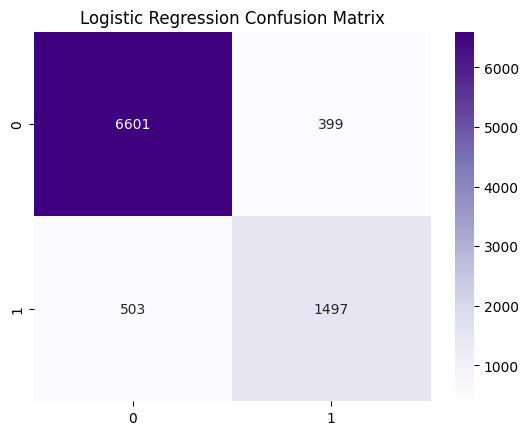

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000

K-Nearest Neighbors Accuracy: 0.8891


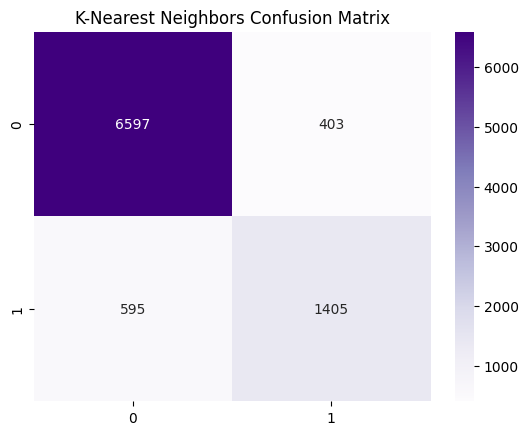

K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      7000
           1       0.78      0.70      0.74      2000

    accuracy                           0.89      9000
   macro avg       0.85      0.82      0.83      9000
weighted avg       0.89      0.89      0.89      9000

Naive Bayes Accuracy: 0.7530


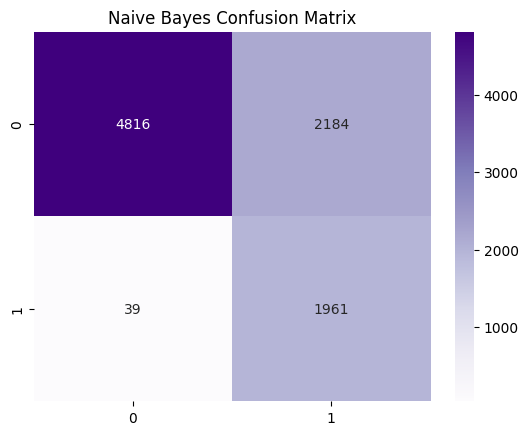

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.69      0.81      7000
           1       0.47      0.98      0.64      2000

    accuracy                           0.75      9000
   macro avg       0.73      0.83      0.73      9000
weighted avg       0.88      0.75      0.77      9000

Support Vector Machine Accuracy: 0.9159


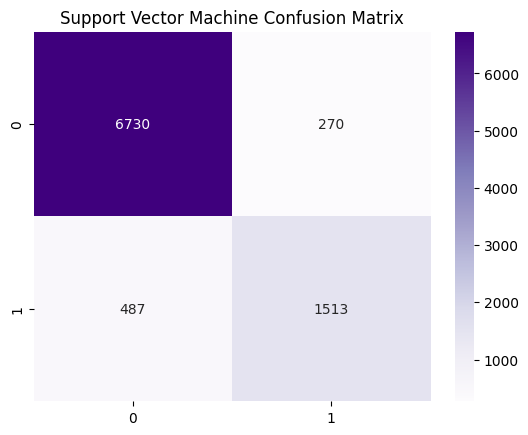

Support Vector Machine Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      7000
           1       0.85      0.76      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.87      9000
weighted avg       0.91      0.92      0.91      9000

Random Forest Accuracy: 0.9296


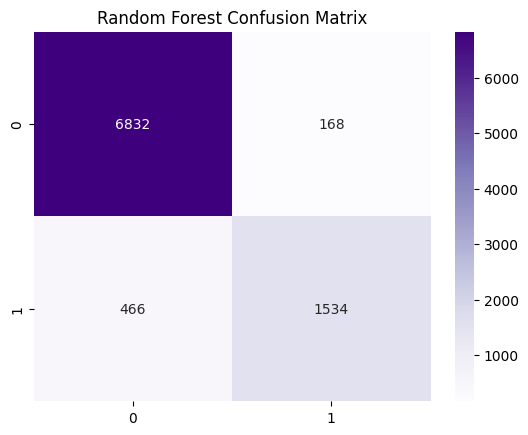

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000

Decision Tree Accuracy: 0.8977


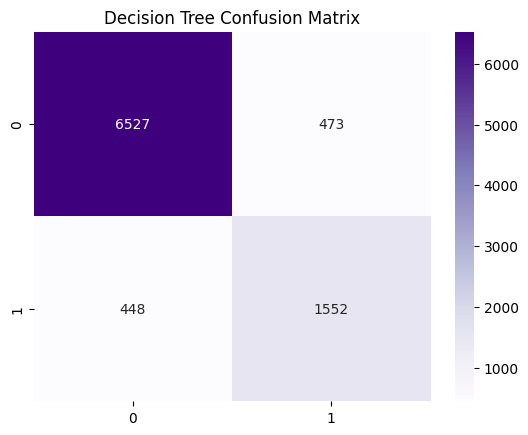

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93      7000
           1       0.77      0.78      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000

XGBoost Accuracy: 0.9354


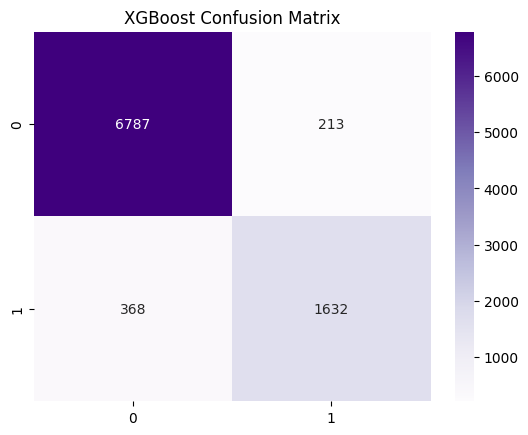

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      7000
           1       0.88      0.82      0.85      2000

    accuracy                           0.94      9000
   macro avg       0.92      0.89      0.90      9000
weighted avg       0.93      0.94      0.93      9000


Model Performance Summary:
Logistic Regression: 0.8998
K-Nearest Neighbors: 0.8891
Naive Bayes: 0.7530
Support Vector Machine: 0.9159
Random Forest: 0.9296
Decision Tree: 0.8977
XGBoost: 0.9354


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning classifiers
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

model_performance = {}

# Helper function to train and evaluate models
def evaluate_model(model, model_name):
    # Fit the model
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # Classification report
    print(f"{model_name} Classification Report:\n", classification_report(y_test, y_pred))

    # Store the accuracy
    model_performance[model_name] = accuracy

# Logistic Regression
logreg = LogisticRegression()
evaluate_model(logreg, "Logistic Regression")

# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=3)  # You can tune this
evaluate_model(knn, "K-Nearest Neighbors")

# Naive Bayes
nb = GaussianNB()
evaluate_model(nb, "Naive Bayes")

# Support Vector Machine (SVM)
svm = SVC(kernel='rbf')  # Linear kernel for simplicity; try 'rbf' for non-linear
evaluate_model(svm, "Support Vector Machine")

# Random Forest
rf = RandomForestClassifier(n_estimators=100)  # You can tune the number of trees
evaluate_model(rf, "Random Forest")

# Decision Tree
dt = DecisionTreeClassifier()
evaluate_model(dt, "Decision Tree")

xgb = XGBClassifier()
evaluate_model(xgb, "XGBoost")

# Summarize model performance
print("\nModel Performance Summary:")
for model_name, accuracy in model_performance.items():
    print(f"{model_name}: {accuracy:.4f}")



Training a neural network

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8573 - loss: 0.3015 - precision: 0.7193 - recall: 0.5874 - val_accuracy: 0.8956 - val_loss: 0.2274 - val_precision: 0.9046 - val_recall: 0.5925
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8892 - loss: 0.2446 - precision: 0.8265 - recall: 0.6359 - val_accuracy: 0.9092 - val_loss: 0.2137 - val_precision: 0.8321 - val_recall: 0.7410
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8906 - loss: 0.2436 - precision: 0.8316 - recall: 0.6421 - val_accuracy: 0.8997 - val_loss: 0.2133 - val_precision: 0.9255 - val_recall: 0.5965
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8936 - loss: 0.2337 - precision: 0.8374 - recall: 0.6471 - val_accuracy: 0.9113 - val_loss: 0.2021 - val_precision: 0.8150 - val_recall: 0.7775
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8910 - loss: 0.2458 - precision: 0.8346 - recall: 0.6228 - val_accuracy: 0.9099 - val_loss:

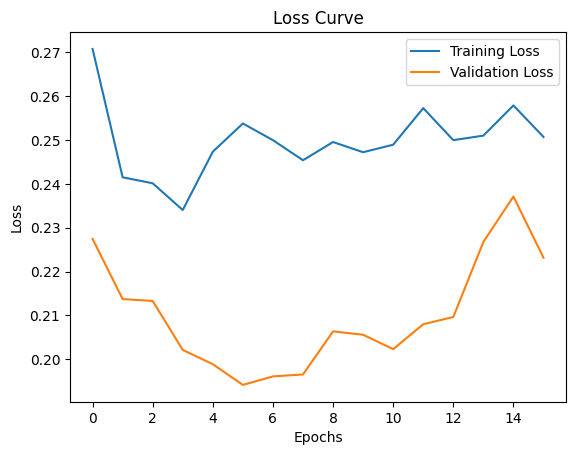

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9138 - loss: 0.1928 - precision: 0.8567 - recall: 0.7395


In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define a deep neural network architecture
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.35),  # Dropout to prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.35),
    Dense(32, activation='relu'),
    Dropout(0.35),
    Dense(16, activation='relu'),
    Dropout(0.35),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])


# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

# Use early stopping to prevent overfittingggg
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Plot the loss curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=1)

Implementing Gridsearch using GridsearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
import numpy as np

# Define a function to create the model
def create_model(learning_rate, dropout_rate, units):
    model = Sequential([
        Dense(units, activation='relu', input_dim=X_train.shape[1]),
        Dropout(dropout_rate),
        Dense(units // 2, activation='relu'),
        Dropout(dropout_rate),
        Dense(units // 4, activation='relu'),
        Dropout(dropout_rate),
        Dense(units // 8, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Wrap the model using KerasClassifier
model = KerasClassifier(
    model=create_model,
    learning_rate=0.01,  # Default values
    dropout_rate=0.35,
    units=128,
    verbose=0
)

# Define the hyperparameter grid
param_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'dropout_rate': [0.2, 0.35, 0.5],
    'units': [64, 128, 256],
    'batch_size': [16, 32],
    'epochs': [50, 100]
}

# Custom scoring functions
def avg_metric_score(y_true, y_pred):
    """Compute the average of accuracy, precision, and recall."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    return (acc + prec + rec) / 3

# Create custom scorers
accuracy_scorer = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)
avg_scorer = make_scorer(avg_metric_score)

# Initialize GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring=avg_scorer  # Use average metric for model selection
)

# Perform the grid search
grid_result = grid.fit(X_train, y_train)

# Display the best hyperparameters and score
print("Best Hyperparameters:", grid_result.best_params_)
print("Best Average Metric Score:", grid_result.best_score_)

# Evaluate on test data using the best model
best_model = grid_result.best_estimator_
y_test_pred = best_model.predict(X_test)

# Compute individual metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
avg_test_score = (test_accuracy + test_precision + test_recall) / 3

# Display the metrics
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Average Test Metric Score: {avg_test_score:.4f}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

KeyboardInterrupt: 